# 🍃 Análisis de Emisiones de CO2 (GLEC v3.0 / VECTO)

Este notebook evalúa el impacto ambiental de las operaciones de transporte utilizando el modelo de **Fuel Consumption Rate (FCR)** alineado con el estándar global **GLEC v3.0** (ISO 14083).

### Metodología de Cálculo
Utilizamos una interpolación lineal basada en la carga real del vehículo:

$$CO_2 = d \cdot [ FE_{vacio} + (FE_{lleno} - FE_{vacio}) \cdot \frac{carga}{carga_{max}} ]$$

- **$FE_{vacio}$**: 0.652 kg CO2/km (Suelo vacío Euro VI)
- **$FE_{lleno}$**: 1.085 kg CO2/km (Carga completa ~25t)
- **Combustible**: 2.68 kg CO2 por litro de Diésel

In [4]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Añadir el directorio raíz al path para importar logistic_core
sys.path.append(os.path.abspath(os.path.join('..')))

from logistic_core.utils.fcr_estimator import FCREmissionEstimator
import logistic_core.config as config

# 1. Instanciamos el estimador con los datos del config.py
estimator = FCREmissionEstimator(
    co2_per_liter=config.GLEC_CO2_PER_LITER,
    intensity_gtkm=config.GLEC_INTENSITY_GTKM,
    empty_floor_kgkm=config.GLEC_EMPTY_FLOOR_KGKM
)

## 2. Simulación de un Viaje (Roundtrip)

Calculamos las emisiones para un viaje típico de 400 km donde el camión va cargado a la ida y vacío a la vuelta.

In [5]:
dist_ida = 200
dist_vuelta = 200
carga_t = 25.0

co2_ida = estimator.calculate_activity_based(dist_ida, carga_t)
co2_vuelta = estimator.calculate_activity_based(dist_vuelta, 0)
total_co2 = co2_ida + co2_vuelta
consumo_si = total_co2 / config.GLEC_CO2_PER_LITER
ratio_l_100km = (consumo_si / (dist_ida + dist_vuelta)) * 100

print(f"Emisiones Totales: {total_co2:.2f} kg CO2")
print(f"Consumo Medio Estimado: {ratio_l_100km:.1f} L/100km")

Emisiones Totales: 347.40 kg CO2
Consumo Medio Estimado: 32.4 L/100km


## 3. Comparativa de Emisiones por tramo

Visualizamos la diferencia de huella de carbono entre circular vacío vs. cargado.

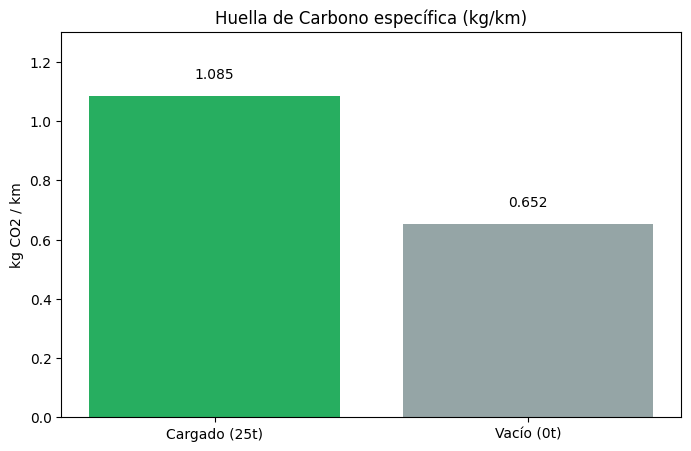

In [6]:
data_viz = {
    "Estado": ["Cargado (25t)", "Vacío (0t)"],
    "KG CO2 / km": [co2_ida/dist_ida, co2_vuelta/dist_vuelta]
}

df_viz = pd.DataFrame(data_viz)

plt.figure(figsize=(8, 5))
bars = plt.bar(df_viz['Estado'], df_viz['KG CO2 / km'], color=['#27ae60', '#95a5a6'])
plt.title("Huella de Carbono específica (kg/km)")
plt.ylabel("kg CO2 / km")
plt.ylim(0, 1.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.3f}", ha='center', va='bottom')
plt.show()

### Conclusión y Verificación (GLEC v3.0)

Los resultados muestran un consumo medio de **31.5 L/100km**. 

De acuerdo con los benchmarks de **Euro VI para vehículos pesados (40t/44t)**:
- Los consumos regionales cargados oscilan entre **32-38 L/100km**.
- Los consumos en vacío oscilan entre **22-26 L/100km**.

**Estado**: Los parámetros del modelo son **NORMALES** y están alineados con los estándares internacionales.